In [38]:
import os
import cmdstanpy

cmdstan_base_dir = "/home/onyxia/work/cmdstan"

# 1. Détection et compilation conditionnelle du backend C++
if not os.path.exists(cmdstan_base_dir) or not any(d.startswith("cmdstan-") for d in os.listdir(cmdstan_base_dir)):
    print(f"Absence du backend C++. Téléchargement et compilation initiés dans {cmdstan_base_dir}...")
    # La compilation nécessite g++ et make (déjà présents sur l'image VSCode Python d'Onyxia)
    cmdstanpy.install_cmdstan(dir=cmdstan_base_dir)

# 2. Assignation stricte du chemin 
try:
    installed_versions = [d for d in os.listdir(cmdstan_base_dir) if d.startswith("cmdstan-")]
    # Trie pour garantir la sélection de la version la plus récente si plusieurs existent
    installed_versions.sort(reverse=True) 
    
    cmdstan_path = os.path.join(cmdstan_base_dir, installed_versions[0])
    cmdstanpy.set_cmdstan_path(cmdstan_path)
    print(f"Liaison matérielle CmdStan établie sur : {cmdstanpy.cmdstan_path()}")
except Exception as e:
    raise RuntimeError(f"Échec critique lors de la résolution des binaires CmdStan : {e}")

Liaison matérielle CmdStan établie sur : /home/onyxia/work/cmdstan/cmdstan-2.39.0


## RHO PAR DYADE, MULTITHREADING, hurdle logit ~alpha + gamma + X_h*beta_h + beta_lag_m49[cluster_h]*is_mig_lag

In [23]:
import warnings

import os
import cmdstanpy
from cmdstanpy import CmdStanModel

import pandas as pd
import numpy as np

import xgboost as xgb
import re
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve , roc_auc_score, accuracy_score
from itertools import product

#from sklearn.ensemble import RandomForestClassifier
from scipy.special import logit as scipy_logit

warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_PATH  = "../data/panel_june_ready.csv"
STAN_FILE  = "../STAN/HMC_hurdle_regression_multithread.stan"
OUTPUT_DIR = "./stan_outputs_tmux"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## D'ici la réunion 8 Juillet 
* réfléchir à un plan/draft; lire du JRSS A 
* dataset: compléter ou réfléchir à exclure proprement les états problématiques. covariables concernées: LA LL urban ; PSE DROM-TOM etc.
* relancer simulation avec Hurdle logit et rf / xgb, et quantifier rho dyadique/cluster 
* résoudre faiblesse hyper-régression
* trancher méthode W_FP
* tester BART sur subsamples et trancher ; on peut le mentionner en Discussion. 


### tester gdpcap_lag1 pour l'horizon 1; réfléchir à la dimension temporelle (prédiction 2011-2014? =/= 2015?)



Var(flow_ij) = E[Var(flow | p_ij)] + Var(E[flow | p_ij])
                    ^ variance volume          ^ variance hurdle
ce deuxième terme est nul quand p_ij est donnée exogène du XGBoost

In [ ]:
# Sampling parameters
N_CHAINS        = 4
PARALLEL_CHAINS = 4
ITER_WARMUP     = 600
ITER_SAMPLING   = 800
THIN            = 2
MAX_TREEDEPTH   = 12
ADAPT_DELTA     = 0.95
N_DRAWS         = ITER_SAMPLING // THIN

# Contrôle matériel : vectorized ou multithreading
USE_MULTITHREADING = False  # True (reduce_sum) / False (Vectorisation standard)


# SUBSET DE PAYS (modifier RUN_SIZE uniquement)
# 1 = 70 pays  
# 2 = 110 pays 
# 3 = 140 pays 
# 4 = run complet
RUN_SIZE = 4


In [25]:
df_main = pd.read_csv(DATA_PATH)
df = df_main[df_main['orig'] != df_main['dest']].copy()

PAYS_EXCLURE = {
    'SSD', 'MNE', 'TLS', 'CUW',
    'GUM', 'MYT', 'VIR', 'CLI', # on va essayer d'intégrer ceux-là manuellement (manque le PIB)
}
df = df[
    ~df['orig'].isin(PAYS_EXCLURE) &
    ~df['dest'].isin(PAYS_EXCLURE)
].copy()

df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)
print(f"{df['orig'].nunique()} pays après exclusions")

192 pays après exclusions


In [26]:



PAYS_SUBSET_70 = {
    'GBR', 'SWE', 'NOR',
    'ITA', 'ESP', 'GRC',
    'FRA', 'DEU', 'NLD',
    'POL', 'ROU', 'UKR',
    'MAR', 'EGY', 'TUN',
    'NGA', 'GHA', 'SEN', 'MLI',
    'ETH', 'KEN', 'SOM', 'TZA',
    'COD', 'CMR', 'CAF',
    'ZAF', 'ZMB',
    'USA', 'CAN', 'MEX',
    'GTM', 'HND',
    'HTI', 'CUB', 'DOM',
    'BRA', 'COL', 'ARG', 'VEN', 'BOL',
    'CHN', 'JPN', 'KOR',
    'IND', 'PAK', 'BGD', 'AFG',
    'IDN', 'PHL', 'THA', 'MMR',
    'KAZ', 'UZB',
    'TUR', 'SAU', 'IRQ', 'SYR', 'ISR',
    'AUS', 'NZL', 'VNM','RUS', 'SLV','CHL','DNK'
}

PAYS_SUBSET_110 = PAYS_SUBSET_70 | {
    'DNK', 'FIN', 'IRL',
    'PRT', 'HRV', 'SRB',
    'BEL', 'CHE', 'AUT',
    'CZE', 'HUN', 'BGR', 'BLR',
    'DZA', 'LBY',
    'CIV', 'GIN', 'BFA', 'NER',
    'RWA', 'UGA', 'MOZ', 'ZWE',
    'AGO', 'GAB', 'COG',
    'NAM', 'BWA',
    'SLV', 'NIC', 'CRI',
    'JAM', 'TTO',
    'CHL', 'PER', 'ECU', 'PRY',
    'MNG', 'PRK',
    'IRN', 'LKA', 'NPL',
    'VNM', 'MYS', 'KHM',
    'KGZ', 'TJK',
    'JOR', 'LBN', 'YEM', 'ARE',
    'PNG', 'FJI',
}

PAYS_SUBSET_140 = PAYS_SUBSET_110 | {
    'EST', 'LVA', 'LTU', 'ISL',
    'ALB', 'MKD', 'BIH', 'MLT',
    'MDA', 'SVK',
    'SDN', 'ESH',
    'GMB', 'LBR', 'SLE', 'CPV', 'GNB', 'BEN', 'TGO',
    'BDI', 'ERI', 'DJI', 'MWI', 'MDG', 'MUS',
    'TCD', 'GNQ', 'STP',
    'LSO', 'SWZ',
    'BLZ', 'PAN',
    #'BHS', 'BRB', 'GRD', 'KNA', 'LCA', 'VCT', 'DMA',
    'GUY', 'SUR', 'URY', 'GUF',
    'HKG', 'MAC',
    'BTN', 'MDV',
    'SGP', 'BRN', 'LAO',
    'TKM',
    #'ARM', 'AZE', 'GEO', 'BHR', 'CYP', 'KWT', 'OMN', 'QAT', 'PSE',
    #'WSM', 'TON', 'SLB', 'VUT', 'KIR',
}

_SUBSETS = {1: PAYS_SUBSET_70, 2: PAYS_SUBSET_110, 3: PAYS_SUBSET_140, 4: None}
_LABELS  = {1: '70 pays', 2: '110 pays', 3: '140 pays', 4: '192 pays (complet)'}

assert RUN_SIZE in _SUBSETS, "RUN_SIZE doit valoir 1, 2, 3 ou 4"

if RUN_SIZE < 4:
    pays_subset = _SUBSETS[RUN_SIZE]
    df = df[df['orig'].isin(pays_subset) & df['dest'].isin(pays_subset)].copy()

print(f"Run : {_LABELS[RUN_SIZE]} — {df['orig'].nunique()} pays effectifs dans le panel")
N_pays= df['orig'].nunique() 
print(f"N_pays={N_pays}")

Run : 192 pays (complet) — 192 pays effectifs dans le panel
N_pays=192


In [27]:
# clustering M49

ISO3_TO_M49_SUBREGION = {
    'DNK': 11, 'EST': 11, 'FIN': 11, 'ISL': 11, 'IRL': 11, 'LVA': 11, 'LTU': 11, 'NOR': 11, 'SWE': 11, 'GBR': 11,
    'ALB': 12, 'AND': 12, 'BIH': 12, 'HRV': 12, 'GRC': 12, 'ITA': 12, 'MLT': 12, 'MNE': 12, 'MKD': 12, 'PRT': 12, 'SRB': 12, 'SVN': 12, 'ESP': 12,
    'AUT': 13, 'BEL': 13, 'FRA': 13, 'DEU': 13, 'LIE': 13, 'LUX': 13, 'MCO': 13, 'NLD': 13, 'CHE': 13,
    'BLR': 14, 'BGR': 14, 'CZE': 14, 'HUN': 14, 'POL': 14, 'MDA': 14, 'ROU': 14, 'RUS': 14, 'SVK': 14, 'UKR': 14,
    'DZA': 15, 'EGY': 15, 'LBY': 15, 'MAR': 15, 'SDN': 15, 'TUN': 15, 'ESH': 15,
    'BEN': 16, 'BFA': 16, 'CPV': 16, 'CIV': 16, 'GMB': 16, 'GHA': 16, 'GIN': 16, 'GNB': 16, 'LBR': 16, 'MLI': 16, 'MRT': 16, 'NER': 16, 'NGA': 16, 'SEN': 16, 'SLE': 16, 'TGO': 16,
    'BDI': 17, 'COM': 17, 'DJI': 17, 'ERI': 17, 'ETH': 17, 'KEN': 17, 'MDG': 17, 'MWI': 17, 'MUS': 17, 'MOZ': 17, 'REU': 17, 'RWA': 17, 'SYC': 17, 'SOM': 17, 'SSD': 17, 'TZA': 17, 'UGA': 17, 'ZMB': 17, 'ZWE': 17,
    'AGO': 18, 'CMR': 18, 'CAF': 18, 'TCD': 18, 'COD': 18, 'COG': 18, 'GNQ': 18, 'GAB': 18, 'STP': 18,
    'BWA': 19, 'LSO': 19, 'NAM': 19, 'ZAF': 19, 'SWZ': 19,
    'CAN': 21, 'MEX': 21, 'USA': 21,
    'BLZ': 22, 'CRI': 22, 'SLV': 22, 'GTM': 22, 'HND': 22, 'NIC': 22, 'PAN': 22,
    'ATG': 23, 'BHS': 23, 'BRB': 23, 'CUB': 23, 'DMA': 23, 'DOM': 23, 'GLP': 23, 'GRD': 23, 'HTI': 23, 'JAM': 23, 'KNA': 23, 'LCA': 23, 'MTQ': 23, 'VCT': 23, 'TTO': 23, 'ABW': 23, 'PRI': 23,
    'ARG': 24, 'BOL': 24, 'BRA': 24, 'CHL': 24, 'COL': 24, 'ECU': 24, 'GUF': 24, 'GUY': 24, 'PRY': 24, 'PER': 24, 'SUR': 24, 'URY': 24, 'VEN': 24,
    'CHN': 30, 'HKG': 30, 'JPN': 30, 'KOR': 30, 'MAC': 30, 'MNG': 30, 'PRK': 30,
    'AFG': 34, 'BGD': 34, 'BTN': 34, 'IND': 34, 'IRN': 34, 'MDV': 34, 'NPL': 34, 'PAK': 34, 'LKA': 34,
    'BRN': 35, 'KHM': 35, 'IDN': 35, 'LAO': 35, 'MYS': 35, 'MMR': 35, 'PHL': 35, 'SGP': 35, 'THA': 35, 'TLS': 35, 'VNM': 35,
    'ARM': 145, 'AZE': 145, 'BHR': 145, 'CYP': 145, 'GEO': 145, 'IRQ': 145, 'ISR': 145, 'JOR': 145, 'KWT': 145, 'LBN': 145, 'OMN': 145, 'QAT': 145, 'SAU': 145, 'PSE': 145, 'SYR': 145, 'TUR': 145, 'ARE': 145, 'YEM': 145,
    'KAZ': 143, 'KGZ': 143, 'TJK': 143, 'TKM': 143, 'UZB': 143,
    'AUS': 53, 'FJI': 53, 'NZL': 53, 'PNG': 53, 'SLB': 53, 'VUT': 53, 'WSM': 53, 'TON': 53, 'KIR': 53, 'FSM': 53, 'GUM': 53, 'NCL': 53, 'PYF': 53,
}

SUBREGION_LABELS = {
    11: 'Europe du Nord', 12: 'Europe du Sud', 13: "Europe de l'Ouest", 14: "Europe de l'Est",
    15: 'Afrique du Nord', 16: "Afrique de l'Ouest", 17: "Afrique de l'Est", 18: 'Afrique Centrale', 19: 'Afrique Australe',
    21: 'Amerique du Nord', 22: 'Amerique Centrale', 23: 'Caraibes', 24: 'Amerique du Sud',
    30: "Asie de l'Est", 34: 'Asie du Sud', 35: 'Asie du Sud-Est',
    143: 'Asie Centrale', 145: "Asie de l'Ouest", 53: 'Oceanie', 99: 'Non classifie'
}

df['m49_brut'] = df['orig'].map(lambda x: ISO3_TO_M49_SUBREGION.get(str(x).upper(), 99))
_UNIQUE_M49_PRESENT = sorted(df['m49_brut'].unique())
_M49_TO_STAN = {m49: i + 1 for i, m49 in enumerate(_UNIQUE_M49_PRESENT)}
stan_to_m49 = {v: k for k, v in _M49_TO_STAN.items()}
df['continent_orig'] = df['m49_brut'].map(_M49_TO_STAN)
K_clusters = len(_M49_TO_STAN)
print(f"{K_clusters} clusters M49")

19 clusters M49


In [28]:
# df['is_migration'] = (df['flow'] > 0).astype(int)
# df['log_flow']     = np.where(df['flow'] > 0, np.log(df['flow']), np.nan)
# df['log_flow_lag'] = df.groupby(['orig', 'dest'])['log_flow'].shift(1)
# df['is_mig_lag']   = df.groupby(['orig', 'dest'])['is_migration'].shift(1)
# df['log_D_ij']     = np.log(df['D_ij'].replace(0, np.nan))
# df['log_D_ij_sq']  = df['log_D_ij'] ** 2
# df['logD_times_LB'] = df['log_D_ij'] * df['LB_ij']


df['dyad'] = df['orig'] + "_" + df['dest']

# df['instability_o'] = df['v2x_clphy_o_lag1'] - df['v2x_polyarchy_o_lag1']
# df['instability_d'] = df['v2x_clphy_d_lag1'] - df['v2x_polyarchy_d_lag1']

df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)

# inutile déjà calculé par build_dataset, à supprimer: 
# for col_base, group_key in [
#     ('intensity_level_o_lag1', 'orig'),
#     ('type_of_conflict_o_lag1', 'orig'),
#     ('intensity_level_d_lag1', 'dest'),
#     ('type_of_conflict_d_lag1', 'dest'),
# ]:
#     new_col = f'{col_base}_persist'
#     df[new_col] = df.groupby([group_key, 'dest' if group_key == 'orig' else 'orig'])[col_base] \
#         .transform(lambda x: x.shift(1).rolling(2, min_periods=1).mean())

df = df.dropna(subset=['is_mig_lag']).reset_index(drop=True)

GRAVITY_VARS_RAW = ['P_it', 'P_jt', 'PSR_i', 'PSR_j', 'IMR_it', 'IMR_jt', 'urban_it', 'urban_jt', 'LA_i', 'LA_j']
for raw in GRAVITY_VARS_RAW:
    df[f'log_{raw}'] = np.log(df[raw].replace(0, np.nan)) # créer les variables log

In [29]:

# HURDLE_VARS RF avec colinéarité 
HURDLE_VARS = [
    'log_D_ij', 'log_D_ij_sq', 'COL_ij', 'OL_ij',
    'v2x_polyarchy_o_lag1', 'v2x_clphy_o_lag1', 'intensity_level_o_lag1',
    'v2x_polyarchy_d_lag1', 'v2x_clphy_d_lag1', 'intensity_level_d_lag1',
]

X_VOL_COLS = [
    'log_D_ij', 'log_D_ij_sq', 'LB_ij', 'OL_ij', 'COL_ij', 't_2000', 't_2000_sq',
    'v2x_polyarchy_o_lag1', 'v2x_clphy_o_lag1', 'intensity_level_o_lag1',
    'v2x_polyarchy_d_lag1', 'v2x_clphy_d_lag1', 'intensity_level_d_lag1', 'type_of_conflict_d_lag1',
]

K_grav = len(X_VOL_COLS)
K_h = len(HURDLE_VARS) + 1 # +1 pour logit_xgb

df_train = df[df['year'] <= 2010].copy()
df_test = df[df['year'] == 2015].copy()
df_test_full = df_test.copy()
df_test_full['dyad'] = df_test_full['orig'] + "_" + df_test_full['dest']
df = df_train

In [30]:
HURDLE_REQUIRED = HURDLE_VARS + [ 'is_migration', 'dyad', 'continent_orig',
                                 'is_mig_lag'
                                 ] 
# covariables + is_mig_lag ne devant pas être standardisée et occupant une place théorique particulière (hystérésis) 
# + variables structurelles  dont Stan a besoin pour l'entraînement et la vraisemblance 
# (dyad pour les effets fixes alpha_i et gamma_j, continent_orig pour les effets de cluster M49)
df_hurdle = df.dropna(subset=HURDLE_REQUIRED).copy().reset_index(drop=True)

VOLUME_REQUIRED = X_VOL_COLS + ['flow', 'log_flow_lag', 'dyad', 'continent_orig']
df_volume = df[df['flow'] > 0].dropna(subset=VOLUME_REQUIRED).copy().reset_index(drop=True)

N_h, N_v = len(df_hurdle), len(df_volume)
print(f"Hurdle : {N_h:,} obs | Volume : {N_v:,} obs")

Hurdle : 180,312 obs | Volume : 89,786 obs


In [31]:
out_degree = df_hurdle.groupby(['orig', 'year'])['is_mig_lag'].sum().reset_index(name='out_degree_o')
in_degree  = df_hurdle.groupby(['dest', 'year'])['is_mig_lag'].sum().reset_index(name='in_degree_d')
df_hurdle  = df_hurdle.merge(out_degree, on=['orig', 'year'], how='left')
df_hurdle  = df_hurdle.merge(in_degree,  on=['dest', 'year'], how='left')
df_hurdle['transitivity_proxy'] = (
    df_hurdle['out_degree_o'].fillna(0) * df_hurdle['in_degree_d'].fillna(0)
)

out_deg_agg = df_hurdle.groupby('orig')['out_degree_o'].mean().reset_index()
in_deg_agg  = df_hurdle.groupby('dest')['in_degree_d'].mean().reset_index()
df_test = df_test.merge(out_deg_agg, on='orig', how='left')
df_test = df_test.merge(in_deg_agg,  on='dest', how='left')
df_test['transitivity_proxy'] = (
    df_test['out_degree_o'].fillna(0) * df_test['in_degree_d'].fillna(0)
)

In [32]:
from sklearn.ensemble import RandomForestClassifier

RF_VARS = [
    'log_D_ij', 'log_D_ij_sq', 'COL_ij', 'OL_ij',
    'v2x_polyarchy_o_lag1', 'v2x_clphy_o_lag1', 'intensity_level_o_lag1',
    'v2x_polyarchy_d_lag1', 'v2x_clphy_d_lag1', 'intensity_level_d_lag1',
    'log_gdpcap_o_lag1', 'log_gdpcap_d_lag1', 'log_gdpcap_diff',
    'log_P_it', 'log_P_jt',
    'is_mig_lag',
    'PSR_i', 'PSR_j',
    'IMR_it', 'IMR_jt',
    'urban_it', 'urban_jt',
    'LL_i', 'LL_j',
    'LA_i', 'LA_j',
    'LB_ij', 'logD_times_LB',
    'type_of_conflict_o_lag1', 'type_of_conflict_d_lag1',
    'transitivity_proxy',
    'v2x_polyarchy_o_lag5', 'v2x_clphy_o_lag5', 'intensity_level_o_lag5', 'type_of_conflict_o_lag5',
    'v2x_polyarchy_d_lag5', 'v2x_clphy_d_lag5', 'intensity_level_d_lag5', 'type_of_conflict_d_lag5',
    'log_stock_lag',
    'any_conflict_o_window', 'max_conflict_o_window', 'any_intense_o_window', 'any_intl_o_window',
    'any_conflict_d_window', 'max_conflict_d_window', 'any_intense_d_window', 'any_intl_d_window',
    'new_conflict_o', 'new_conflict_d', 'persistent_conflict_o', 'persistent_conflict_d',
]

eps = 1e-6

RF_VARS_PRESENT = [c for c in RF_VARS if c in df_hurdle.columns]
print(f"Variables RF : {len(RF_VARS_PRESENT)}")

X_rf_train = df_hurdle[RF_VARS_PRESENT].fillna(0).values
y_rf_train = df_hurdle['is_migration'].values

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_rf_train, y_rf_train)

auc_train = roc_auc_score(y_rf_train, rf_model.predict_proba(X_rf_train)[:, 1])
print(f"RF AUC train : {auc_train:.4f}")

# Injection du logit RF comme covariable de la régression Hurdle (modèle n°1)
proba_rf_train = rf_model.predict_proba(X_rf_train)[:, 1].clip(eps, 1 - eps)
df_hurdle['logit_rf'] = scipy_logit(proba_rf_train)

RF_VARS_TEST = [c for c in RF_VARS_PRESENT if c in df_test.columns]
proba_rf_test = rf_model.predict_proba(df_test[RF_VARS_TEST].fillna(0).values)[:, 1].clip(eps, 1 - eps)
df_test['proba_rf'] = proba_rf_test
df_test['logit_rf'] = scipy_logit(proba_rf_test)

HURDLE_VARS = HURDLE_VARS + ['logit_rf']
K_h = len(HURDLE_VARS)
print(f"K_h : {K_h}")


Variables RF : 52


RF AUC train : 0.9845
K_h : 11


In [33]:
df_test['log_flow_lag_clean'] = (
    df_test['log_flow_lag'].fillna(0.0).replace([np.inf, -np.inf], 0.0)
)

BINARY_COLS_VOL = ['LB_ij', 'OL_ij', 'COL_ij']
BINARY_COLS_HUR = ['LB_ij', 'COL_ij', 'OL_ij','logit_rf'] # pas de standardisation de logit_xgb car si sa variance est forte, beta_h doit exploser et le Hurdle est trop confiant 

def standardize_matrix(X, col_names, binary_cols, fit_stats=None):
    X_std, stats = X.copy().astype(float), {}
    for j, col in enumerate(col_names):
        if col not in binary_cols:
            mu = X[:, j].mean() if fit_stats is None else fit_stats[col]['mean']
            sd = X[:, j].std()  if fit_stats is None else fit_stats[col]['std']
            sd = max(sd, 1e-8)
            X_std[:, j] = (X[:, j] - mu) / sd
            stats[col] = {'mean': mu, 'std': sd}
        else:
            stats[col] = {'mean': 0.0, 'std': 1.0}
    return X_std, stats

dyades_h = sorted(df_hurdle['dyad'].unique())
dyad_to_h = {d: i + 1 for i, d in enumerate(dyades_h)}
df_hurdle['dyad_id_h'] = df_hurdle['dyad'].map(dyad_to_h)
D_h = len(dyades_h)
cluster_h = (
    df_hurdle.groupby('dyad')['continent_orig'].first()
    .reindex([k for k, v in sorted(dyad_to_h.items(), key=lambda x: x[1])])
    .values.astype(int)
)

dyades_v = sorted(df_volume['dyad'].unique())
dyad_to_v = {d: i + 1 for i, d in enumerate(dyades_v)}
df_volume['dyad_id_v'] = df_volume['dyad'].map(dyad_to_v)
D_v = len(dyades_v)
cluster_v = (
    df_volume.groupby('dyad')['continent_orig'].first()
    .reindex([k for k, v in sorted(dyad_to_v.items(), key=lambda x: x[1])])
    .values.astype(int)
)

X_vol_std, stats_vol = standardize_matrix(df_volume[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL)
X_h_std,   stats_h   = standardize_matrix(df_hurdle[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR)

In [34]:
df_test['dyad'] = df_test['orig'] + "_" + df_test['dest']
df_test['dyad_id_test']   = df_test['dyad'].map(dyad_to_h)
df_test['dyad_id_test_v'] = df_test['dyad'].map(dyad_to_v).fillna(0).astype(int)
df_test = df_test.dropna(subset=['dyad_id_test']).copy().reset_index(drop=True)
df_test = df_test.dropna(subset=['log_gdpcap_d_lag'] + HURDLE_VARS + X_VOL_COLS).copy().reset_index(drop=True)
df_test['dyad_id_test'] = df_test['dyad_id_test'].astype(int)

df_test['m49_brut'] = df_test['orig'].map(lambda x: ISO3_TO_M49_SUBREGION.get(str(x).upper(), 99))
df_test['continent_orig_fill'] = df_test['m49_brut'].map(_M49_TO_STAN).fillna(K_clusters).astype(int)
cluster_test_h = df_test['continent_orig_fill'].values  # toujours nécessaire pour rho_m49[k] et phi_disp_cluster[k] dans Stan


X_test_v_std, _ = standardize_matrix(df_test[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL, fit_stats=stats_vol)
X_test_h_std, _ = standardize_matrix(df_test[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR, fit_stats=stats_h)


tous_les_pays = sorted(list(set(df['orig'].unique()).union(set(df['dest'].unique()))))
pays_to_id    = {pays: i + 1 for i, pays in enumerate(tous_les_pays)}
N_pays_total  = len(tous_les_pays)

df_volume['orig_id_v'] = df_volume['orig'].map(pays_to_id)
df_volume['dest_id_v'] = df_volume['dest'].map(pays_to_id)
df_hurdle['orig_id_h'] = df_hurdle['orig'].map(pays_to_id)
df_hurdle['dest_id_h'] = df_hurdle['dest'].map(pays_to_id)
df_test['orig_id_test_v'] = df_test['orig'].map(pays_to_id)
df_test['dest_id_test_v'] = df_test['dest'].map(pays_to_id)

print(f"Test OOS : {len(df_test):,} obs")

Test OOS : 35,526 obs


In [35]:
K_Z = 1
Z_mat = np.zeros((N_pays_total, K_Z))

# Dernière période d'entraînement disponible par pays
df_last = df_train[df_train['year'] == df_train['year'].max()]  # year == 2010
#df_last = df_test[df_test['year'] == 2015]  

for pays, pays_id in pays_to_id.items():
    idx = pays_id - 1

    sub_orig = df_last[df_last['orig'] == pays]
    sub_dest = df_last[df_last['dest'] == pays]

    if not sub_orig.empty:
        log_mass = sub_orig['log_P_it'].iloc[0] + sub_orig['log_gdpcap_o_lag1'].iloc[0]
    elif not sub_dest.empty:
        log_mass = sub_dest['log_P_jt'].iloc[0] + sub_dest['log_gdpcap_d_lag1'].iloc[0]
    else:
        log_mass = np.nan

    Z_mat[idx, 0] = log_mass

col_median = np.nanmedian(Z_mat[:, 0])
for idx, pays in enumerate(pays_to_id.keys()):
    if np.isnan(Z_mat[idx, 0]):
        m49 = ISO3_TO_M49_SUBREGION.get(pays, 99)
        pays_meme_region = [p for p, m in ISO3_TO_M49_SUBREGION.items()
                            if m == m49 and p in pays_to_id]
        vals_region = [Z_mat[pays_to_id[p] - 1, 0]
                       for p in pays_meme_region
                       if not np.isnan(Z_mat[pays_to_id[p] - 1, 0])]
        Z_mat[idx, 0] = np.median(vals_region) if vals_region else col_median
Z_mat[:, 0] = (Z_mat[:, 0] - np.mean(Z_mat[:, 0])) / np.std(Z_mat[:, 0])

Z_em = Z_mat
Z_at = Z_mat

print(f"Z_mat — NaN résiduels : {np.isnan(Z_mat).sum()} | min : {Z_mat.min():.2f} | max : {Z_mat.max():.2f}")

Z_mat — NaN résiduels : 0 | min : -2.46 | max : 2.78


# penser à prendre le PIB courant de 2010 une fois dispo dans le dataset

In [36]:
df_hurdle = df_hurdle.replace([np.inf, -np.inf], np.nan).dropna(subset=HURDLE_REQUIRED)
df_volume = df_volume.replace([np.inf, -np.inf], np.nan).dropna(subset=VOLUME_REQUIRED)
N_h, N_v = len(df_hurdle), len(df_volume)
assert np.isinf(df_volume[X_VOL_COLS].values).sum() == 0

stan_data = {
    # Dimensions globales 
    'N_pays'     : N_pays_total,
    'K_clusters' : int(K_clusters),

    # Hyper-régression 
    'K_Z'  : int(K_Z),
    'Z_em' : Z_em.tolist(),
    'Z_at' : Z_at.tolist(),

    # URDLE (train)
    'N_h'        : int(N_h),
    'D_h'        : int(D_h),
    'K_h'        : int(K_h),
    'dyad_id_h'  : df_hurdle['dyad_id_h'].astype(int).tolist(),
    'orig_id_h'  : df_hurdle['orig_id_h'].astype(int).tolist(),
    'dest_id_h'  : df_hurdle['dest_id_h'].astype(int).tolist(),
    'is_mig'     : df_hurdle['is_migration'].astype(int).tolist(),
    'is_mig_lag' : df_hurdle['is_mig_lag'].astype(float).tolist(),
    'X_h'        : X_h_std.tolist(),
    'cluster_h'  : cluster_h.tolist(),

    #  VOLUME (train) 
    'N_v'          : int(N_v),
    'D_v'          : int(D_v),
    'K_v'          : int(K_grav),
    'dyad_id_v'    : df_volume['dyad_id_v'].astype(int).tolist(),
    'orig_id_v'    : df_volume['orig_id_v'].astype(int).tolist(),
    'dest_id_v'    : df_volume['dest_id_v'].astype(int).tolist(),
    'flow'         : df_volume['flow'].astype(int).tolist(),
    'log_flow_lag' : df_volume['log_flow_lag'].astype(float).tolist(),
    'X_v'          : X_vol_std.tolist(),
    'cluster_v'    : cluster_v.tolist(),

    # TEST OOS — commun
    'N_test'         : int(len(df_test)),
    'cluster_test_h' : cluster_test_h.tolist(),

    # TEST OOS — Hurdle 
    'dyad_id_test_h'  : df_test['dyad_id_test'].astype(int).tolist(),
    'X_h_test'        : X_test_h_std.tolist(),
    'is_mig_lag_test' : df_test['is_mig_lag'].fillna(0.0).tolist(),

    # TEST OOS — Volume
    'dyad_id_test_v'    : df_test['dyad_id_test_v'].astype(int).tolist(),
    'orig_id_test_v'    : df_test['orig_id_test_v'].astype(int).tolist(),
    'dest_id_test_v'    : df_test['dest_id_test_v'].astype(int).tolist(),
    'X_v_test'          : X_test_v_std.tolist(),
    'log_flow_lag_test' : df_test['log_flow_lag_clean'].tolist(),

    # Flags 
    'do_ppc' : 0,
    'do_loo' : 0,
}

# Contrôle d'intégrité 
anomalies = 0
for key, val in stan_data.items():
    if isinstance(val, (list, np.ndarray)):
        arr = np.array(val)
        if np.issubdtype(arr.dtype, np.number):
            if np.isnan(arr).sum() + np.isinf(arr).sum() > 0:
                print(f"[ERREUR] {key}")
                anomalies += 1
if anomalies == 0:
    print("stan_data : 0 NaN, 0 Inf")

stan_data : 0 NaN, 0 Inf


In [ ]:




if USE_MULTITHREADING:
    STAN_FILE = "../STAN/HMC_hurdle_regression_multithread.stan"
    THREADS_PER_CHAIN = 4  # Saturation des 12 P-cores (3 threads * 4 chaînes)
else:
    STAN_FILE = "../STAN/HMC_hurdle_regression_vectorized.stan"


# Purge du binaire précédent pour prévenir la corruption du cache compilateur
binary = STAN_FILE.replace('.stan', '')
if os.path.exists(binary):
    os.remove(binary)

# 1. Compilation Asymétrique
if USE_MULTITHREADING:
    model = CmdStanModel(
        stan_file=STAN_FILE,
        cpp_options={'STAN_THREADS': 'true'}
    )
    sample_kwargs = {'threads_per_chain': THREADS_PER_CHAIN}
    arch_suffix = "MT"
else:
    model = CmdStanModel(
        stan_file=STAN_FILE,
        compile='force' 
    )
    sample_kwargs = {} 
    arch_suffix = "VECT"

N_pays = df['orig'].nunique()

# Échantillonnage HMC-NUTS
fit = model.sample(
    data              = stan_data,
    chains            = N_CHAINS,
    parallel_chains   = PARALLEL_CHAINS,
    iter_warmup       = ITER_WARMUP,
    iter_sampling     = ITER_SAMPLING,
    save_warmup       = False,
    seed              = 42,
    inits             = 0.1,
    thin              = THIN,
    adapt_delta       = ADAPT_DELTA,
    max_treedepth     = MAX_TREEDEPTH,
    show_progress     = True,
    sig_figs          = 4,
    output_dir        = OUTPUT_DIR,
    **sample_kwargs   # Déballage dynamique : injecte threads_per_chain uniquement si défini
)

# Traçabilité des logs
custom_prefix = f"ARX_{N_pays}pays_{N_CHAINS}c_{ITER_SAMPLING}it_{arch_suffix}"
renamed_csvs = []
for i, old_path in enumerate(fit.runset.csv_files):
    new_path = os.path.join(OUTPUT_DIR, f"{custom_prefix}_chain{i+1}.csv")
    os.replace(old_path, new_path)
    renamed_csvs.append(new_path)

print(f"Outputs : {custom_prefix}_chain*.csv")


18:28:40 - cmdstanpy - INFO - compiling stan file /home/onyxia/work/bayesForecasts/STAN/HMC_hurdle_regression_multithread.stan to exe file /home/onyxia/work/bayesForecasts/STAN/HMC_hurdle_regression_multithread
18:29:20 - cmdstanpy - INFO - compiled model executable: /home/onyxia/work/bayesForecasts/STAN/HMC_hurdle_regression_multithread
18:29:29 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/1700 [00:00<?, ?it/s, (Warmup)]





chain 1:   0%|          | 1/1700 [00:04<2:06:04,  4.45s/it, (Warmup)]18:30:14 - cmdstanpy - ERROR - CmdStan error: code '-2' Unknown error -2


KeyboardInterrupt: 

In [ ]:
CSV_PREFIX    = f"ARX_{N_pays}pays_{N_CHAINS}c_{ITER_SAMPLING}it"
csv_files = [
    f"{OUTPUT_DIR}/{CSV_PREFIX}_chain{i+1}.csv"
    for i in range(N_CHAINS)
]

with open(csv_files[0], 'r') as f:
    for line in f:
        if not line.startswith('#'):
            all_cols = line.strip().split(',')
            break

vars_to_keep = [
     'mu_dt_test', 'phi_test',
    'beta_grav',  #'beta_lag_m49',
    'phi_disp_global', 'phi_disp_cluster',
    'rho_global_monitor', 'tau_rho',
    'tau_em', 'tau_at', 'intercept_em', 'intercept_at',
    
    'theta_em', 'theta_at', 
    'tau_phi_disp', #'rho_m49',
    #'mu_beta_lag', 'sigma_beta_lag',
    'divergent__', 'treedepth__', 'energy__', 'stepsize__',
]

cols_keep = [c for c in all_cols if any(c.startswith(v) for v in vars_to_keep)]
print(f"Colonnes extraites : {len(cols_keep)}")

dfs = []
for f in csv_files:
    print(f"Lecture {f}...")
    dfs.append(pd.read_csv(f, comment='#', usecols=cols_keep, engine='c'))

df_final = pd.concat(dfs, ignore_index=True)
del dfs
print(f"RAM : {df_final.memory_usage().sum() / 1024**2:.1f} Mo")

Colonnes extraites : 2162
Lecture ./stan_outputs_tmux/ARX_33pays_2c_800it_chain1.csv...
Lecture ./stan_outputs_tmux/ARX_33pays_2c_800it_chain2.csv...
RAM : 13.2 Mo


In [ ]:
#prob_mig        = df_final.filter(like='prob_mig_test').values
mu_test         = df_final.filter(like='mu_dt_test').values
phi_t           = df_final.filter(like='phi_test').values
beta_grav       = df_final.filter(like='beta_grav').values
#beta_h          = df_final.filter(like='beta_h').values
phi_disp_cluster = df_final.filter(like='phi_disp_cluster').values
rho_m49_draws    = df_final.filter(like='rho_m49').values



print(f"mu_test shape : {mu_test.shape}")

mu_test shape : (800, 1056)


In [ ]:
valid_draws = ~(
    np.isnan(mu_test).any(axis=1) |
    np.isnan(phi_t).any(axis=1)
)
mu_clean  = mu_test[valid_draws]
phi_clean = phi_t[valid_draws]
print(f"Tirages nettoyés : {mu_test.shape[0] - valid_draws.sum()} retirés")

eta_safe = np.clip(mu_clean, -50.0, 50.0)
phi_safe = np.clip(phi_clean, 1e-8, 1e8)
lam      = np.exp(eta_safe)
n_sp     = phi_safe
p_sp     = np.clip(phi_safe / (phi_safe + lam), 1e-10, 1.0 - 1e-10)

flow_cond_sim = np.random.negative_binomial(n_sp, p_sp)
zeros_mask    = (flow_cond_sim == 0)
max_retries, retries = 30, 0
while zeros_mask.any() and retries < max_retries:
    flow_cond_sim[zeros_mask] = np.random.negative_binomial(n_sp[zeros_mask], p_sp[zeros_mask])
    zeros_mask = (flow_cond_sim == 0)
    retries   += 1
if zeros_mask.any():
    flow_cond_sim[zeros_mask] = 1

flow_cond_med_final = np.median(flow_cond_sim, axis=0)

# Hurdle : XGB seul, pas de draws Stan
prob_med = df_test['proba_xgb'].values

Tirages nettoyés : 0 retirés


In [ ]:
y_true     = df_test['flow'].values
y_true_bin = (y_true > 0).astype(int)

W_FP_global  = 25.0
cluster_test = df_test['continent_orig_fill'].values

fpr_ref, tpr_ref, thresh_ref = roc_curve(y_true_bin, prob_med)
score_ref         = tpr_ref - (W_FP_global * fpr_ref)
optimal_threshold = thresh_ref[np.argmax(score_ref)]

seuil_par_cluster = {}
wp_par_cluster    = {}

for cluster_id in np.unique(cluster_test):
    mask_c = (cluster_test == cluster_id)
    n_pos  = y_true_bin[mask_c].sum()
    n_neg  = (1 - y_true_bin[mask_c]).sum()
    if n_pos < 30 or n_neg < 30:
        fpr_g, tpr_g, thresh_g = roc_curve(y_true_bin, prob_med)
        seuil_par_cluster[cluster_id] = thresh_g[np.argmax(tpr_g - W_FP_global * fpr_g)]
        wp_par_cluster[cluster_id]    = W_FP_global
        continue
    ratio        = n_neg / n_pos
    ratio_global = (1 - y_true_bin).sum() / y_true_bin.sum()
    wp_c         = np.clip(W_FP_global * (ratio / ratio_global), 2.0, 50.0)
    wp_par_cluster[cluster_id] = wp_c
    fpr_c, tpr_c, thresh_c = roc_curve(y_true_bin[mask_c], prob_med[mask_c])
    seuil_par_cluster[cluster_id] = thresh_c[np.argmax(tpr_c - wp_c * fpr_c)]
    label = SUBREGION_LABELS.get(stan_to_m49.get(cluster_id, 99), f'cluster_{cluster_id}')
    print(f"  {label:<30} seuil={seuil_par_cluster[cluster_id]:.3f}  WP={wp_c:.1f}  n_pos={n_pos}  n_neg={n_neg}")

y_pred_bin_cluster = np.zeros(len(y_true_bin), dtype=int)
for cluster_id, seuil_c in seuil_par_cluster.items():
    mask_c = (cluster_test == cluster_id)
    y_pred_bin_cluster[mask_c] = (prob_med[mask_c] > seuil_c).astype(int)

y_pred     = np.where(y_pred_bin_cluster == 1, flow_cond_med_final, 0.0)
y_pred_bin = y_pred_bin_cluster

# Intervalles de confiance : prob XGB broadcast sur les draws volume
prob_clean = np.tile(prob_med, (mu_clean.shape[0], 1))
is_mig_sim = np.random.binomial(1, np.clip(prob_clean, 0, 1))
flow_all   = is_mig_sim * flow_cond_sim
y_pred_q05 = np.percentile(flow_all, 2.5,  axis=0)
y_pred_q95 = np.percentile(flow_all, 97.5, axis=0)

print(f"\nSeuil global de référence : {optimal_threshold:.3f}")

  Afrique de l'Est               seuil=0.963  WP=45.4  n_pos=118  n_neg=42
  Amerique Centrale              seuil=0.914  WP=50.0  n_pos=30  n_neg=34

Seuil global de référence : 0.995


In [ ]:
acc        = accuracy_score(y_true_bin, y_pred_bin)
global_mae = np.mean(np.abs(y_true - y_pred))
mape_wr    = np.mean(np.abs(y_true - y_pred) / (y_true + 1.0)) * 100
wmape      = np.sum(np.abs(y_true - y_pred)) / (np.sum(y_true) + 1e-8) * 100
log_mae    = np.mean(np.abs(np.log1p(y_true) - np.log1p(y_pred)))
coverage   = np.mean((y_true >= y_pred_q05) & (y_true <= y_pred_q95))

print(f"Accuracy Hurdle   : {acc*100:.1f}%")
print(f"MAE               : {global_mae:,.0f}")
print(f"MAPE (W&R)        : {mape_wr:.1f}%")
print(f"WMAPE             : {wmape:.1f}%")
print(f"Log-MAE           : {log_mae:.4f}")
print(f"Coverage 95%      : {coverage*100:.1f}%")
print()
print(f"{'Modèle':<40} | {'MAE':>10} | {'MAPE':>10} | {'Coverage':>10}")
print("-" * 78)
print(f"{'Welch & Raftery (2022)':<40} | {'~1,200':>10} | {'76.0%':>10} | {'93.0%':>10}")
print(f"{f'Hurdle ARX ZTNB ({N_pays} pays)':<40} | {global_mae:>10,.0f} | {f'{mape_wr:.1f}%':>10} | {f'{coverage*100:.1f}%':>10}")

Accuracy Hurdle   : 88.0%
MAE               : 48,434
MAPE (W&R)        : 219.2%
WMAPE             : 314.4%
Log-MAE           : 1.1903
Coverage 95%      : 98.9%

Modèle                                   |        MAE |       MAPE |   Coverage
------------------------------------------------------------------------------
Welch & Raftery (2022)                   |     ~1,200 |      76.0% |      93.0%
Hurdle ARX ZTNB (33 pays)                |     48,434 |     219.2% |      98.9%


In [ ]:
# Tableau de diagnostic bayésien

SCALAIRES = [
    'rho_global_monitor', 'tau_rho', 'tau_em', 'tau_at',
     'intercept_em', 'intercept_at',
    
    'phi_disp_global', 'tau_phi_disp' 
]

VECTORIELS = {
    'beta_grav'        : X_VOL_COLS,
    #'beta_h'           : HURDLE_VARS,
    #'beta_lag_m49'     : [f'cluster_{k}' for k in range(1, K_clusters + 1)],
    'theta_em'         : [f'Z_{k}' for k in range(1, K_Z + 1)],
    'theta_at'         : [f'Z_{k}' for k in range(1, K_Z + 1)],
    #'theta_h_em'       : [f'Z_{k}' for k in range(1, K_Z + 1)],
    #'theta_h_at'       : [f'Z_{k}' for k in range(1, K_Z + 1)],
    'phi_disp_cluster' : [SUBREGION_LABELS.get(stan_to_m49.get(k, 99), f'cluster_{k}') for k in range(1, K_clusters + 1)],
    'rho_m49'          : [SUBREGION_LABELS.get(stan_to_m49.get(k, 99), f'cluster_{k}') for k in range(1, K_clusters + 1)],
}

def ess_bulk(draws):
    from scipy.stats import rankdata
    n = len(draws)
    if n < 4:
        return np.nan
    r  = rankdata(draws) / (n + 1)
    z  = np.where(r < 0.5, -np.sqrt(2)*np.log(1/(2*r)), np.sqrt(2)*np.log(1/(2*(1-r))))
    mu = z.mean()
    var = z.var()
    if var < 1e-10:
        return n
    ac1 = np.corrcoef(z[:-1], z[1:])[0, 1]
    rho = max(ac1, 0)
    return round(n * (1 - rho) / (1 + rho))

def rhat(chains_draws):
    m  = len(chains_draws)
    n  = min(len(c) for c in chains_draws)
    chains = np.array([c[:n] for c in chains_draws])
    B  = n * np.var(chains.mean(axis=1), ddof=1)
    W  = np.mean([np.var(chains[i], ddof=1) for i in range(m)])
    return round(np.sqrt(((n-1)/n * W + B/n) / W), 4) if W > 0 else np.nan

def summarize_param(name, draws_all, chains_draws):
    q = np.percentile(draws_all, [5, 25, 50, 75, 95])
    sig = '*' if (q[0] > 0 or q[4] < 0) else ''
    return {'Paramètre': name, 'Médiane': round(q[2], 4),
            'IC 5%': round(q[0], 4), 'IC 95%': round(q[4], 4),
            'ESS': ess_bulk(draws_all), 'R-hat': rhat(chains_draws), 'Sig': sig}

rows = []
for param in SCALAIRES:
    cols = [c for c in df_final.columns if c == param or c.startswith(f'{param}[')]
    for col in cols:
        d_all = df_final[col].dropna().values.astype(float)
        d_chains = [df_final[col].iloc[i*N_DRAWS:(i+1)*N_DRAWS].dropna().values.astype(float) for i in range(N_CHAINS)]
        rows.append(summarize_param(col if len(cols) > 1 else param, d_all, d_chains))

for param, labels in VECTORIELS.items():
    unsorted = [c for c in df_final.columns if c.startswith(f'{param}[')]
    cols = sorted(unsorted, key=lambda x: int(re.search(r'\[(\d+)\]', x).group(1)) if '[' in x else 0)
    for j, col in enumerate(cols):
        d_all = df_final[col].dropna().values.astype(float)
        d_chains = [df_final[col].iloc[i*N_DRAWS:(i+1)*N_DRAWS].dropna().values.astype(float) for i in range(N_CHAINS)]
        label = labels[j] if j < len(labels) else f'[{j+1}]'
        rows.append(summarize_param(f'{param}[{label}]', d_all, d_chains))

summary_df = pd.DataFrame(rows)

print(f"{'Paramètre':<35} {'Médiane':>9} {'IC 5%':>9} {'IC 95%':>9} {'ESS':>6} {'R-hat':>7} {'Sig':>4}")
print("-" * 85)
for _, r in summary_df.iterrows():
    flag = ' !' if (r['R-hat'] > 1.01 or r['ESS'] < 400) else ''
    print(f"{r['Paramètre']:<35} {r['Médiane']:>9.4f} {r['IC 5%']:>9.4f} {r['IC 95%']:>9.4f} "
          f"{int(r['ESS']) if not np.isnan(r['ESS']) else 'NaN':>6} {r['R-hat']:>7.4f} {r['Sig']:>4}{flag}")

n_div = int(df_final.get('divergent__', pd.Series([0])).sum())
pct_tree = (df_final['treedepth__'] >= 10).mean() * 100 if 'treedepth__' in df_final.columns else None
print(f"\nDivergences : {n_div}")
if pct_tree is not None:
    print(f"Treedepth saturé (>=10) : {pct_tree:.1f}%")
bad = summary_df[(summary_df['R-hat'] > 1.01) | (summary_df['ESS'] < 400)]
print(f"Paramètres hors seuils : {len(bad)}")

Paramètre                             Médiane     IC 5%    IC 95%    ESS   R-hat  Sig
-------------------------------------------------------------------------------------
rho_global_monitor                     0.2192    0.1789    0.2607    339  1.0243    * !
tau_rho                                0.0694    0.0473    0.1088    503  1.0010    *
tau_em                                 0.8266    0.6891    0.9822    499  0.9996    *
tau_at                                 0.6760    0.5572    0.8108    447  1.0021    *
intercept_em                           3.4805    2.3587    4.6372    800  1.0005    *
intercept_at                           3.3945    2.2979    4.5489    800  0.9989    *
phi_disp_global                        0.8088    0.6127    1.0200    557  0.9994    *
tau_phi_disp                           1.0910    1.0020    1.1810    351  1.0081    * !

Divergences : 0
Treedepth saturé (>=10) : 0.0%
Paramètres hors seuils : 2



[ VOLUME (ZTNB) ]
Variable                     Moyenne      IC 5%     IC 95%   Sig
-----------------------------------------------------------------
log_D_ij                       0.949      0.428      1.512   OUI
log_D_ij_sq                   -1.902     -2.460     -1.388   OUI
LB_ij                          2.172      1.844      2.497   OUI
OL_ij                          0.898      0.716      1.079   OUI
COL_ij                         2.065      1.836      2.305   OUI
t_2000                        -0.300     -0.385     -0.222   OUI
t_2000_sq                      0.412      0.354      0.476   OUI
v2x_polyarchy_o_lag1          -0.135     -0.346      0.066   non
v2x_clphy_o_lag1              -0.086     -0.254      0.102   non
intensity_level_o_lag1         0.078      0.022      0.138   OUI
v2x_polyarchy_d_lag1          -0.165     -0.319     -0.012   OUI
v2x_clphy_d_lag1               0.224      0.070      0.363   OUI
intensity_level_d_lag1         0.502      0.351      0.648   OUI
type_

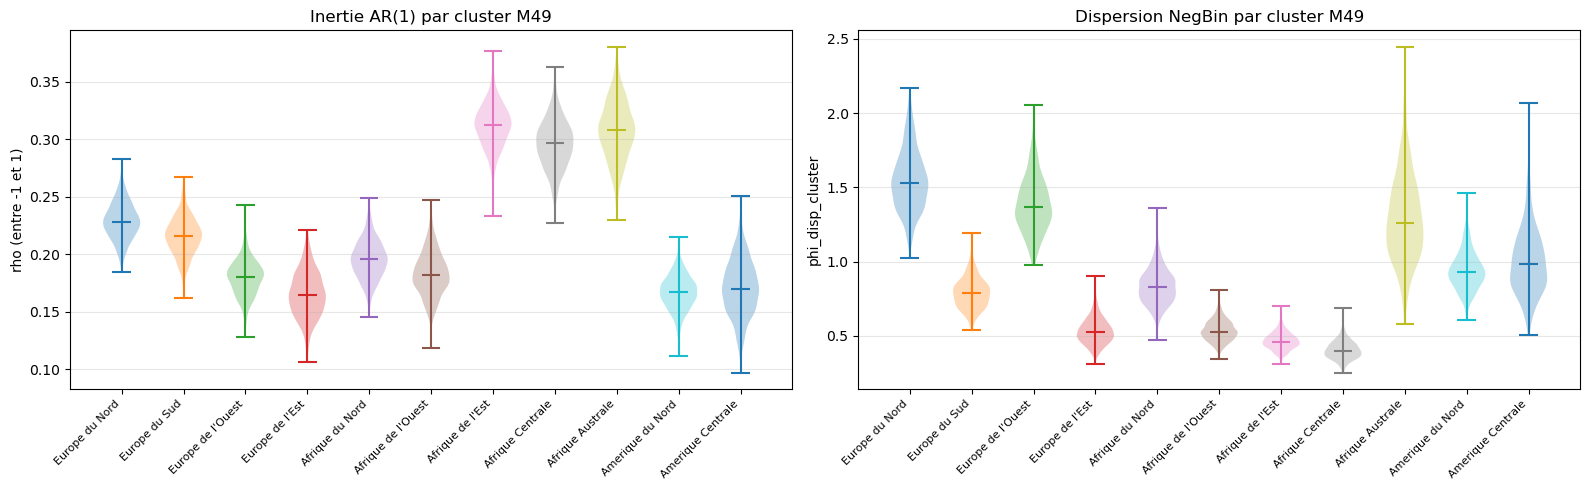

In [ ]:
# Tableau des coefficients Hurdle et Volume
def print_coef_table(name, means, q05, q95, labels):
    print(f"\n[ {name} ]")
    print(f"{'Variable':<25} {'Moyenne':>10} {'IC 5%':>10} {'IC 95%':>10} {'Sig':>5}")
    print("-" * 65)
    for j in range(len(means)):
        col = labels[j] if j < len(labels) else f'[{j+1}]'
        sig = 'OUI' if (q05[j] > 0 or q95[j] < 0) else 'non'
        print(f"{col:<25} {means[j]:>10.3f} {q05[j]:>10.3f} {q95[j]:>10.3f} {sig:>5}")

# print_coef_table(
#     'HURDLE (Logit)',
#     beta_h.mean(axis=0),
#     np.percentile(beta_h, 5, axis=0),
#     np.percentile(beta_h, 95, axis=0),
#     HURDLE_VARS
# )

print_coef_table(
    'VOLUME (ZTNB)',
    beta_grav.mean(axis=0),
    np.percentile(beta_grav, 5, axis=0),
    np.percentile(beta_grav, 95, axis=0),
    X_VOL_COLS
)
rho_m49_draws       = df_final.filter(like='rho_m49').values
phi_cluster_draws   = df_final.filter(like='phi_disp_cluster').values
cluster_labels      = [SUBREGION_LABELS.get(stan_to_m49.get(k, 99), f'cluster_{k}')
                       for k in range(1, K_clusters + 1)]

print_coef_table(
    'RHO AR(1) par cluster M49',
    rho_m49_draws.mean(axis=0),
    np.percentile(rho_m49_draws,  5, axis=0),
    np.percentile(rho_m49_draws, 95, axis=0),
    cluster_labels
)

print_coef_table(
    'PHI dispersion par cluster M49',
    phi_cluster_draws.mean(axis=0),
    np.percentile(phi_cluster_draws,  5, axis=0),
    np.percentile(phi_cluster_draws, 95, axis=0),
    cluster_labels
)

# Figure comparative rho vs phi par cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, draws, title, ylabel in [
    (axes[0], rho_m49_draws,     'Inertie AR(1) par cluster M49',       'rho (entre -1 et 1)'),
    (axes[1], phi_cluster_draws, 'Dispersion NegBin par cluster M49',   'phi_disp_cluster'),
]:
    for k in range(draws.shape[1]):
        ax.violinplot(draws[:, k], positions=[k + 1], widths=0.6, showmedians=True)
    ax.set_xticks(range(1, K_clusters + 1))
    ax.set_xticklabels(cluster_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"rho_phi_cluster_M49_{N_pays}.pdf", bbox_inches='tight')
plt.show()

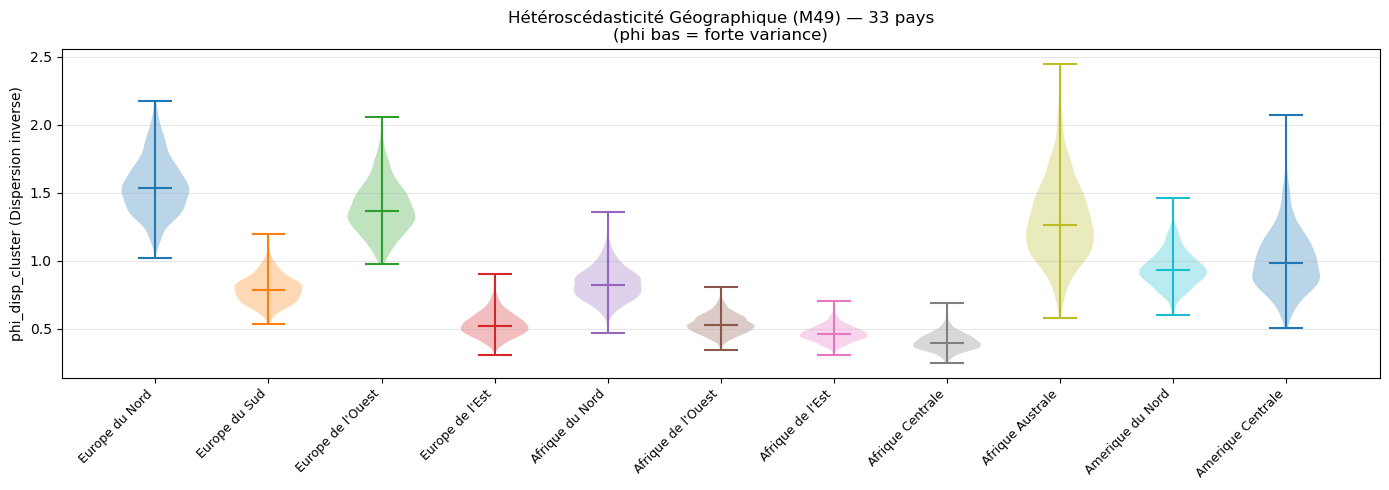

In [ ]:
# Figure : hétéroscédasticité M49
fig, ax = plt.subplots(figsize=(14, 5))
for k in range(1, K_clusters + 1):
    draws_k = phi_disp_cluster[:, k-1].flatten()
    ax.violinplot(draws_k, positions=[k], widths=0.6, showmedians=True)
ax.set_xticks(range(1, K_clusters + 1))
ax.set_xticklabels(
    [SUBREGION_LABELS.get(stan_to_m49.get(k, 99), f'Cluster {k}') for k in range(1, K_clusters + 1)],
    rotation=45, ha='right', fontsize=9
)
ax.set_ylabel("phi_disp_cluster (Dispersion inverse)")
ax.set_title(f"Hétéroscédasticité Géographique (M49) — {N_pays} pays\n(phi bas = forte variance)")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f"NegBin_dispersion_cluster_M49_{N_pays}.pdf", bbox_inches='tight')
plt.show()

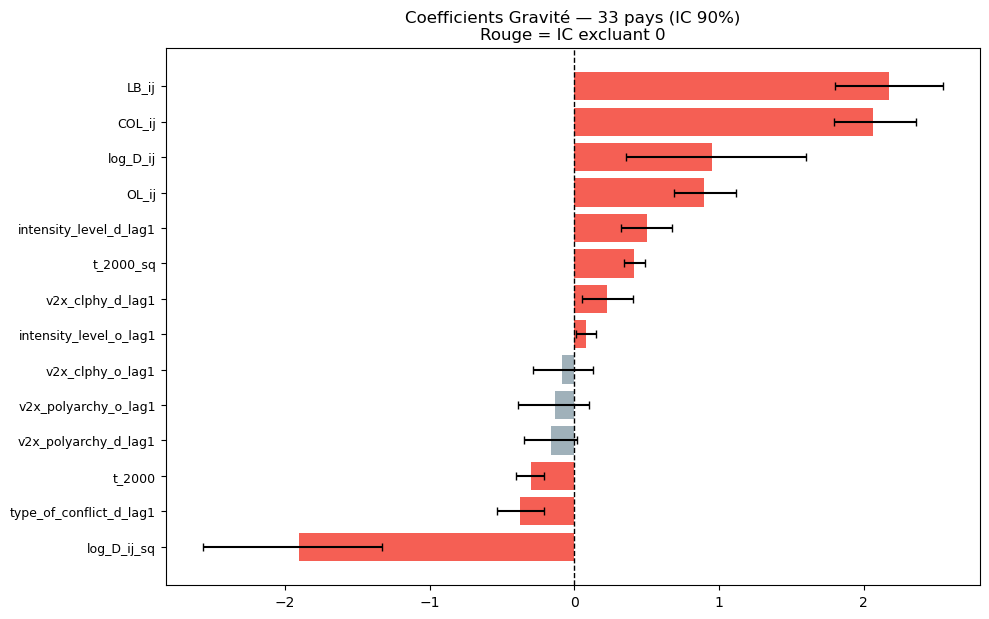

In [ ]:
# Figure : coefficients Hurdle et Volume
def plot_coefs(means, q05, q95, labels, title, color_sig, fname):
    K = len(means)
    order = np.argsort(means)
    colors = [color_sig if (q05[i] > 0 or q95[i] < 0) else '#90A4AE' for i in order]
    fig, ax = plt.subplots(figsize=(10, max(5, K * 0.45)))
    ax.barh(
        range(K), means[order],
        xerr=[means[order] - q05[order], q95[order] - means[order]],
        color=colors, alpha=0.85, capsize=3
    )
    ax.set_yticks(range(K))
    ax.set_yticklabels([labels[i] for i in order], fontsize=9)
    ax.axvline(0, color='black', lw=1, ls='--')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

# plot_coefs(
#     beta_h.mean(axis=0), np.percentile(beta_h, 2.5, axis=0), np.percentile(beta_h, 97.5, axis=0),
#     HURDLE_VARS,
#     f"Coefficients Hurdle — {N_pays} pays (IC 95%)\nBleu = IC excluant 0",
#     '#2196F3', f"NegBin_hurdle_coefficients_{N_pays}.pdf"
# )

plot_coefs(
    beta_grav.mean(axis=0), np.percentile(beta_grav, 2.5, axis=0), np.percentile(beta_grav, 97.5, axis=0),
    X_VOL_COLS,
    f"Coefficients Gravité — {N_pays} pays (IC 90%)\nRouge = IC excluant 0",
    '#F44336', f"NegBin_gravity_coefficients_{N_pays}.pdf"
)

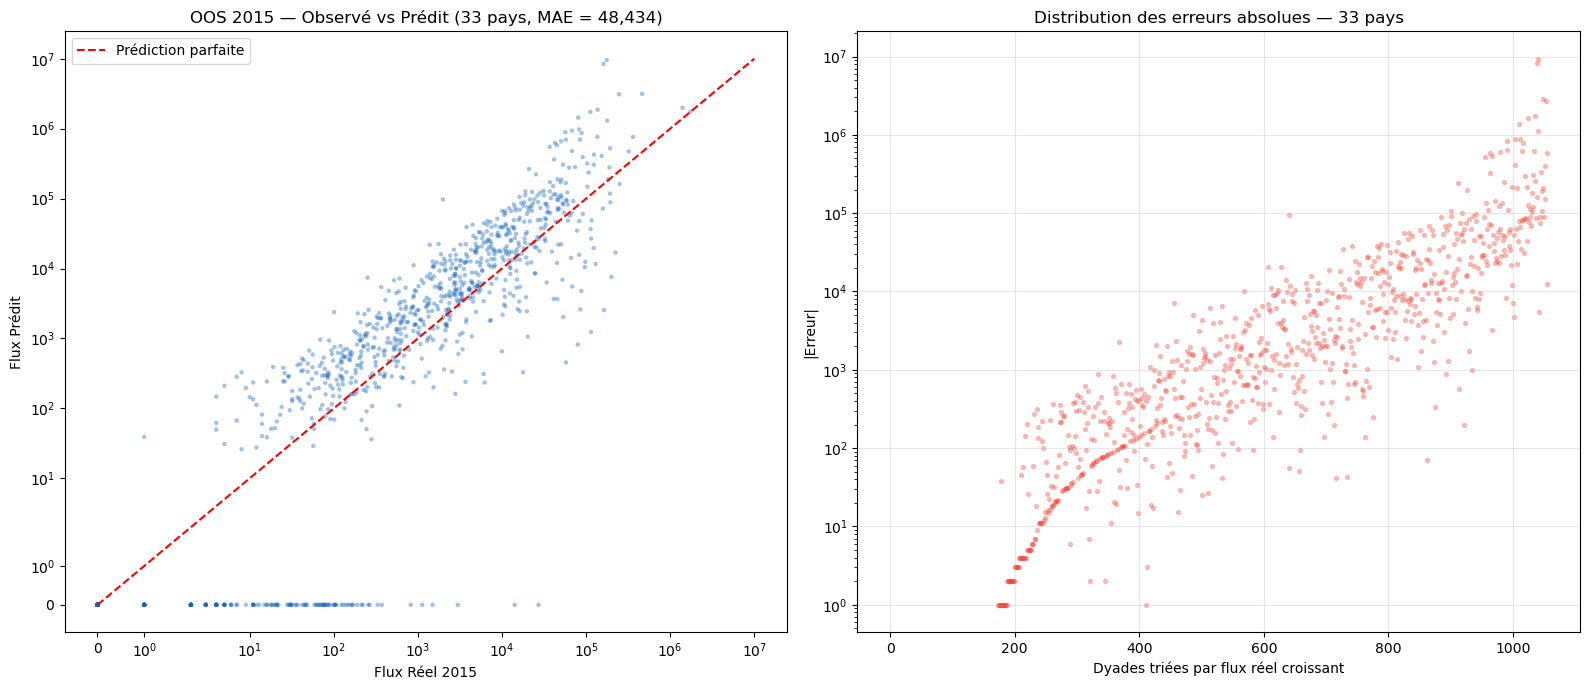

In [ ]:
# Figure : scatter OOS + distribution des erreurs
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.4, s=10, color='#1565C0', edgecolors='none')
lim = [0, max(y_true.max(), y_pred.max()) * 1.05]
ax.plot(lim, lim, 'r--', lw=1.5, label='Prédiction parfaite')
ax.set_xscale('symlog')
ax.set_yscale('symlog')
ax.set_xlabel("Flux Réel 2015")
ax.set_ylabel("Flux Prédit")
ax.set_title(f"OOS 2015 — Observé vs Prédit ({N_pays} pays, MAE = {global_mae:,.0f})")
ax.legend()

ax2 = axes[1]
order_err = np.argsort(y_true)
ax2.scatter(range(len(y_true)), np.abs(y_true[order_err] - y_pred[order_err]),
            alpha=0.3, s=8, color='#F44336')
ax2.set_xlabel("Dyades triées par flux réel croissant")
ax2.set_ylabel("|Erreur|")
ax2.set_yscale('log')
ax2.set_title(f"Distribution des erreurs absolues — {N_pays} pays")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"NegBin_prediction_scatter_{N_pays}.pdf", bbox_inches='tight')
plt.show()

In [ ]:
# Cartographie FP / FN
import plotly.express as px

df_test['y_true_bin'] = y_true_bin
df_test['y_pred_bin'] = y_pred_bin
df_test['FN'] = ((df_test['y_true_bin'] == 1) & (df_test['y_pred_bin'] == 0)).astype(int)
df_test['FP'] = ((df_test['y_true_bin'] == 0) & (df_test['y_pred_bin'] == 1)).astype(int)

error_map = df_test.groupby('orig')[['FN', 'FP']].sum().reset_index()
print(f"FN : {df_test['FN'].sum()} | FP : {df_test['FP'].sum()}")

for col, scale, title in [
    ('FN', 'Reds',  'Cartographie Faux Négatifs (FN) par pays d\'origine'),
    ('FP', 'Blues', 'Cartographie Faux Positifs (FP) par pays d\'origine'),
]:
    fig = px.choropleth(
        error_map, locations='orig', color=col,
        hover_name='orig', color_continuous_scale=scale,
        title=title, labels={col: f'Nombre de {col}'}
    )
    fig.update_layout(geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'))
    fig.show()

FN : 127 | FP : 0
